In [1]:
# Welcome back, I am excited to showcase this next part!
# This moves up a folder to access the juicy .py data
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

In [2]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from pathlib import Path
import data as dt
import models as md
import backtest as bt
output_dir = Path("../Outputs")
output_dir.mkdir(exist_ok=True)
print("Imports Ok")

Imports Ok


In [3]:
airline_returns, macro_returns, prices = dt.load_data()
train = airline_returns[airline_returns.index <= dt.train_end]
covs = md.rolling_covariances(train, window=md.lookback, use_ledoit_wolf = True)
print(f"Covariance matrices: {len(covs)} dates")

Airlines: 7 tickers
Macro: 4 tickers
Dates: 2903 trading days
Range: 2015-01-05 -> 2026-07-16
Training: 2015-01-05 -> 2019-12-31
Validation: 2022-01-01 -> 2026-07-16
Covariance matrices: 1167 dates


In [20]:
systematic, residuals, evals_df, evecs_df, expl_df = md.compute_factor_model(train, covs, md.n_components)
print("Average explained variance (training):")
print(expl_df.mean().round(4))
print(f"Total: {expl_df.mean().sum():.1%}")

Average explained variance (training):
PC1    0.6094
PC2    0.1490
PC3    0.0762
dtype: float64
Total: 83.5%


In [21]:
# Autocorrelation test — tells you: mean reversion or momentum?
# Negative lag-1 autocorrelation → mean reversion (use default mode)
# Positive lag-1 autocorrelation → momentum (use momentum=True)

from statsmodels.stats.stattools import durbin_watson

print("Residual Autocorrelation by Lag")
print(f"{'Ticker':<8}  {'Lag1':>8}  {'Lag2':>8}  {'Lag5':>8}  {'DW':>8}  {'Regime':>14}")
print("─" * 62)

for col in residuals.columns:
    r = residuals[col].dropna()
    ac1 = r.autocorr(lag=1)
    ac2 = r.autocorr(lag=2)
    ac5 = r.autocorr(lag=5)
    dw = durbin_watson(r)
    # DW ≈ 2.0: no autocorrelation
    # DW < 1.5: positive autocorrelation (momentum)
    # DW > 2.5: negative autocorrelation (mean reversion)
    regime = ("MOMENTUM" if ac1 > 0.05
              else "MEAN REV" if ac1 < -0.05
              else "NOISE")
    print(f"{col:<8}  {ac1:>8.4f}  {ac2:>8.4f}  {ac5:>8.4f}  {dw:>8.4f}  {regime:>14}")

print(f"If most tickers show MOMENTUM → use momentum=True in generate_signals()")
print(f"If most show MEAN REV → use momentum=False (current default)")
print(f"If most show NOISE → signals have no edge at this frequency")

Residual Autocorrelation by Lag
Ticker        Lag1      Lag2      Lag5        DW          Regime
──────────────────────────────────────────────────────────────
DAL         0.0350    0.0143    0.0135    1.9274           NOISE
UAL         0.0517    0.0103   -0.0219    1.8961        MOMENTUM
AAL         0.0092   -0.0029    0.0221    1.9754           NOISE
LUV         0.0011    0.0183   -0.0033    1.9957           NOISE
ALK        -0.0018   -0.0047    0.0481    2.0012           NOISE
JBLU       -0.0266   -0.0396    0.0273    2.0511           NOISE
CPA        -0.0237   -0.0676    0.1109    2.0471           NOISE
If most tickers show MOMENTUM → use momentum=True in generate_signals()
If most show MEAN REV → use momentum=False (current default)
If most show NOISE → signals have no edge at this frequency


In [22]:
# Given the white noise overload from OU, we shall move over to zscores
zscore_window = 20
zscores = md.compute_rolling_zscore(residuals, window = zscore_window).dropna()
zscores = zscores.ewm(span=5, min_periods=2).mean()

print(f"After EMA smoothing, z-score range:")
print(zscores.abs().describe().round(3))
print(f"\nEntry threshold: {bt.entry_threshold}")
print(f"% of values exceeding threshold: "
      f"{(zscores.abs() > bt.entry_threshold).mean().mean():.2%}")

After EMA smoothing, z-score range:
            DAL       UAL       AAL       LUV       ALK      JBLU       CPA
count  1157.000  1157.000  1157.000  1157.000  1157.000  1157.000  1157.000
mean      0.371     0.355     0.345     0.340     0.344     0.352     0.346
std       0.287     0.287     0.268     0.300     0.274     0.280     0.292
min       0.001     0.001     0.000     0.001     0.000     0.000     0.001
25%       0.146     0.137     0.127     0.117     0.129     0.136     0.125
50%       0.309     0.282     0.293     0.258     0.287     0.290     0.269
75%       0.530     0.514     0.503     0.458     0.480     0.495     0.488
max       1.721     1.616     1.448     2.314     1.665     1.559     1.635

Entry threshold: 1.5
% of values exceeding threshold: 0.30%


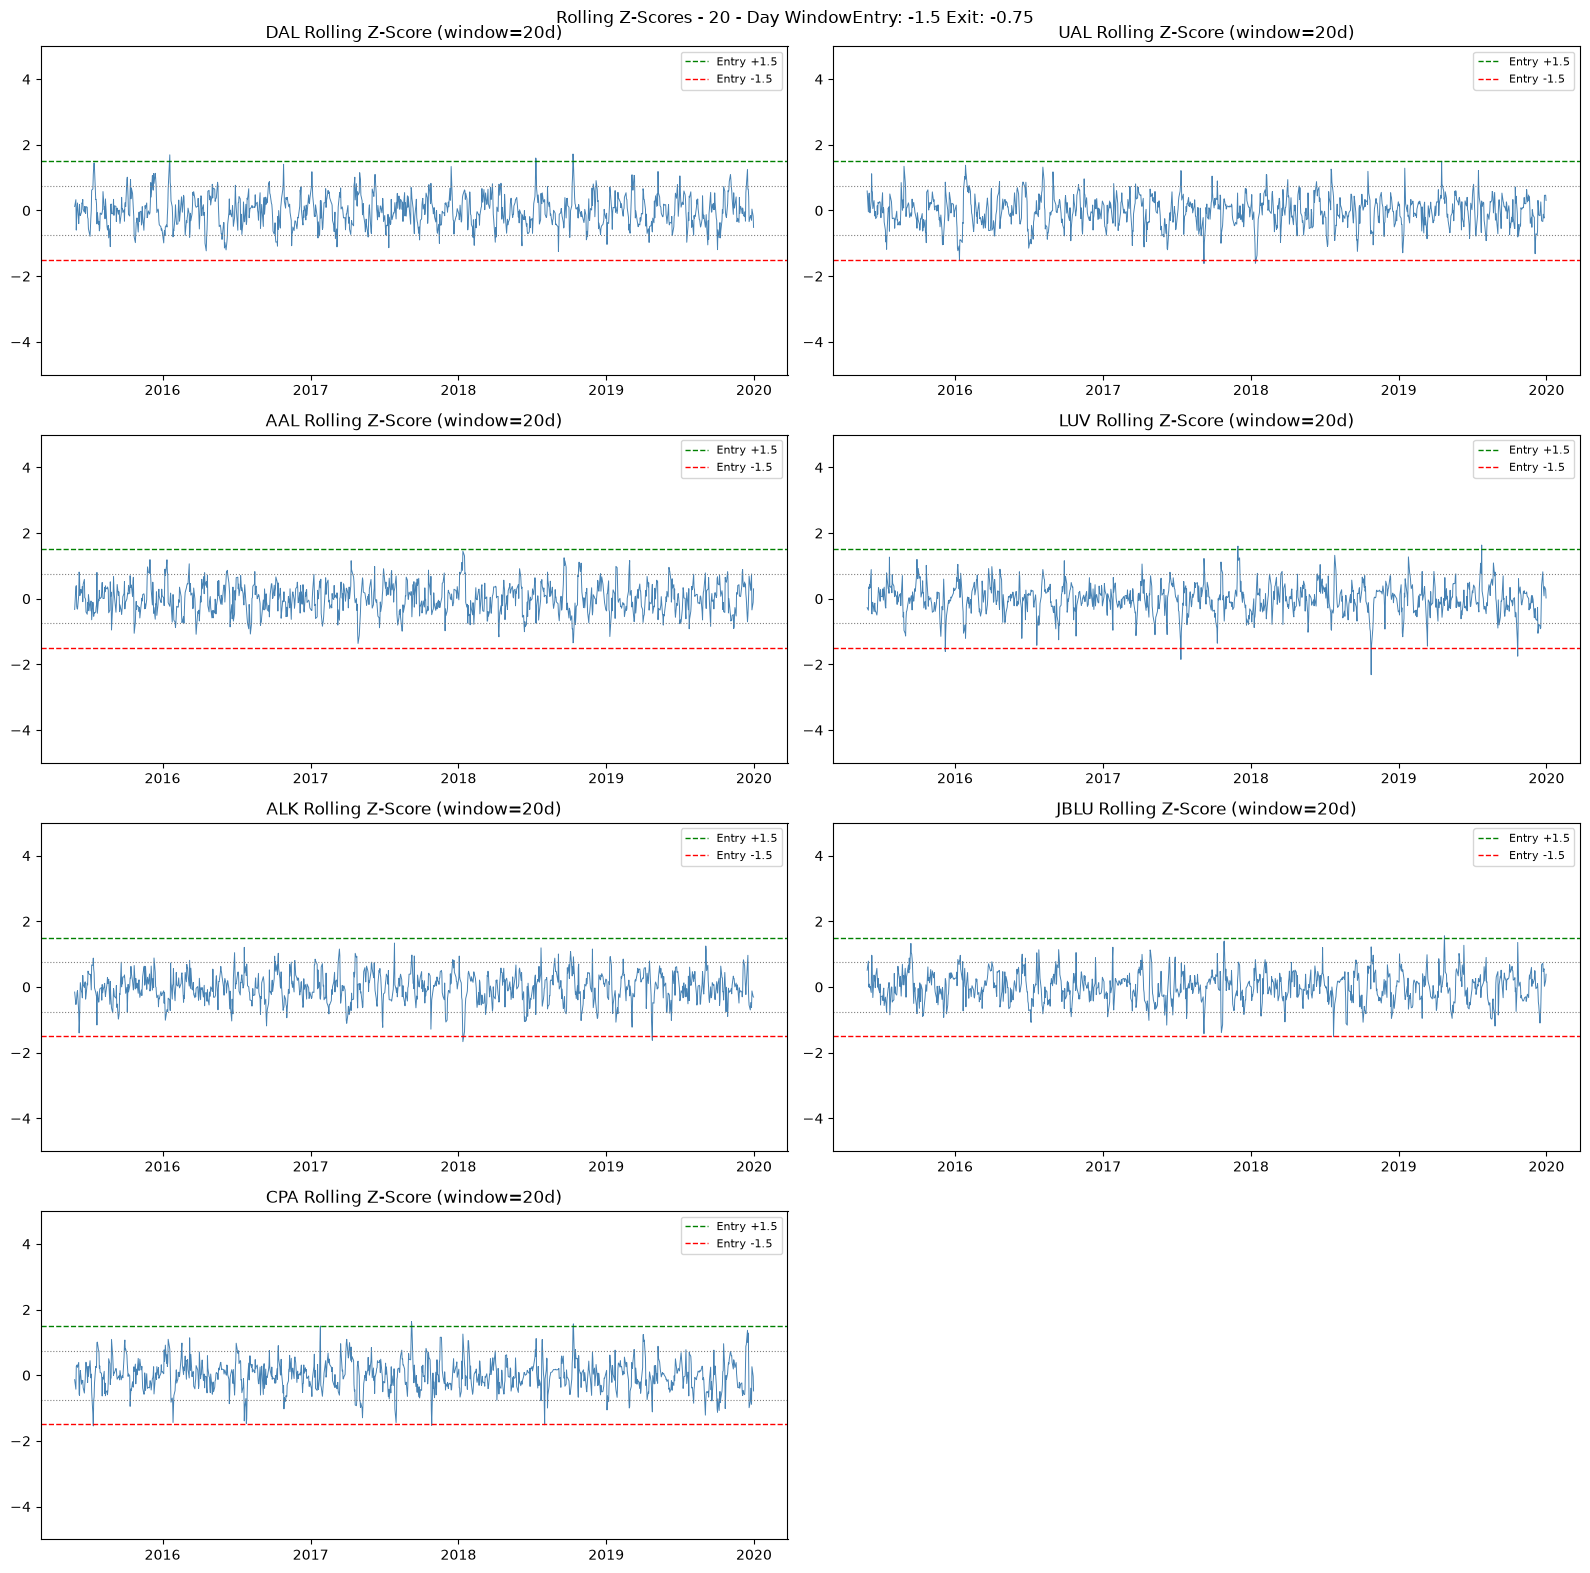

In [23]:
fig, axes = plt.subplots(4, 2, figsize=(16, 16))
axes = axes.flatten()
for i, col in enumerate(residuals.columns):
    z = zscores[col].dropna()
    axes[i].plot(z.index, z.values, linewidth=0.7, color='steelblue')
    axes[i].axhline( bt.entry_threshold, color='green', linestyle='--',
                     linewidth=1.0, label=f'Entry +{bt.entry_threshold}')
    axes[i].axhline(-bt.entry_threshold, color='red',   linestyle='--',
                     linewidth=1.0, label=f'Entry -{bt.entry_threshold}')
    axes[i].axhline( bt.exit_threshold,  color='gray',  linestyle=':',
                     linewidth=0.8)
    axes[i].axhline(-bt.exit_threshold,  color='gray',  linestyle=':',
                     linewidth=0.8)
    axes[i].set_title(f"{col} Rolling Z-Score (window={zscore_window}d)")
    axes[i].set_ylim(-5, 5)
    axes[i].legend(fontsize=8)
if len(residuals.columns) < len(axes):
    axes[-1].set_visible(False)
plt.suptitle(f"Rolling Z-Scores - {zscore_window} - Day Window"
             f"Entry: -{bt.entry_threshold} Exit: -{bt.exit_threshold}",
             fontsize=12)
plt.tight_layout()
plt.show()

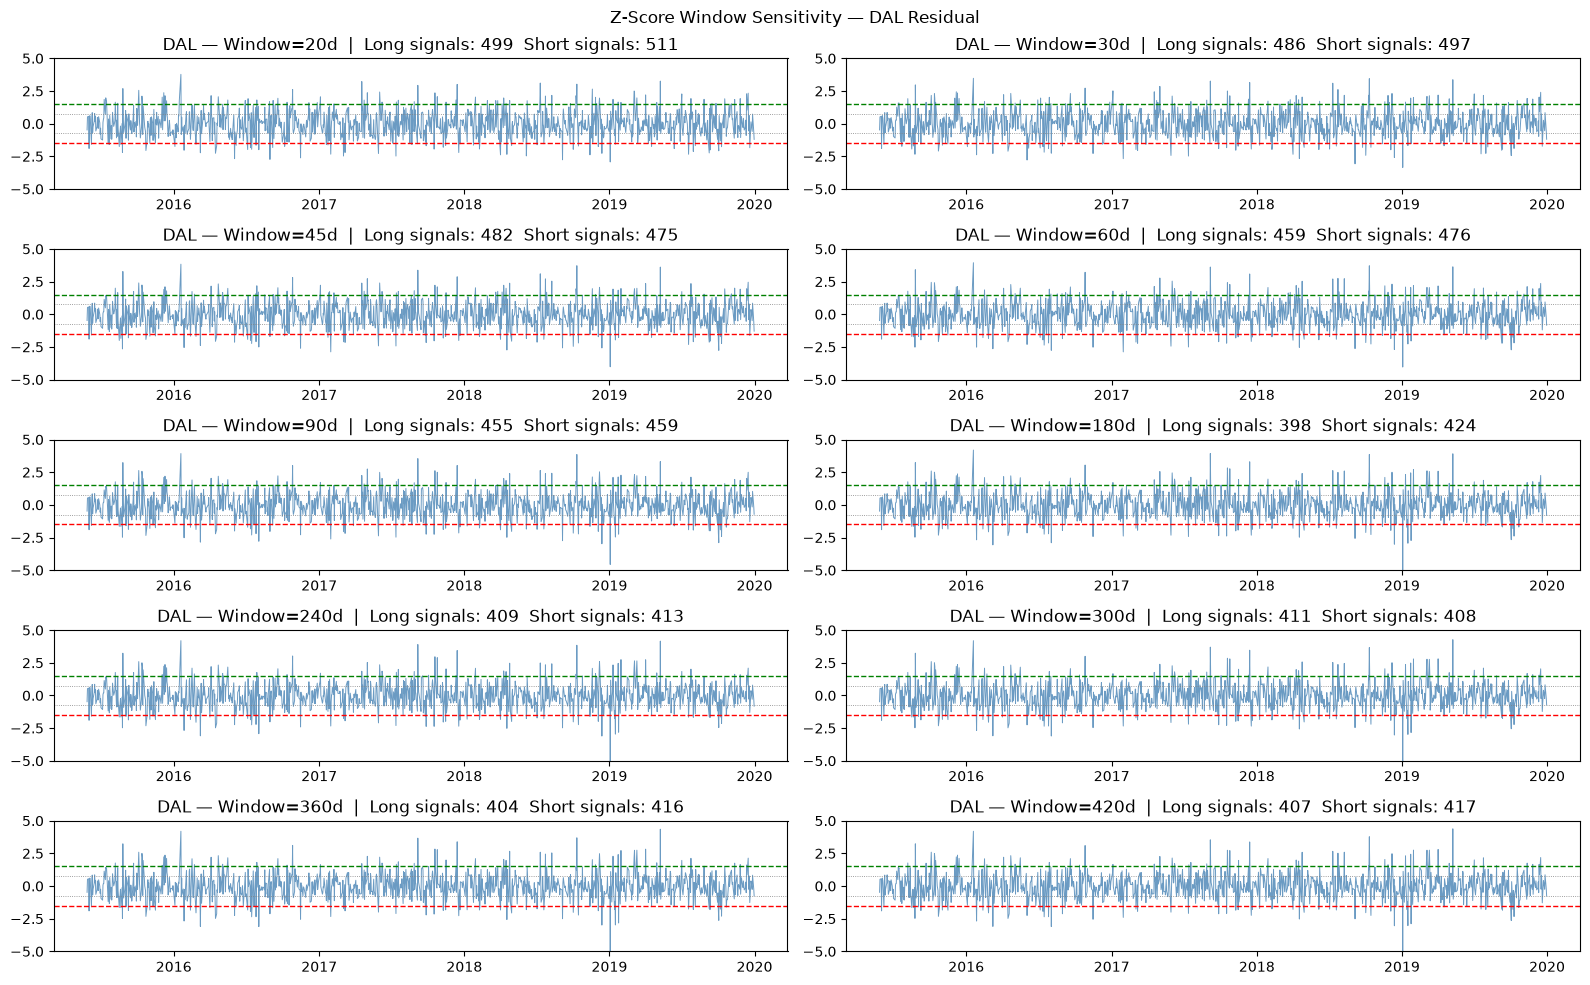

<function matplotlib.pyplot.show(close=None, block=None)>

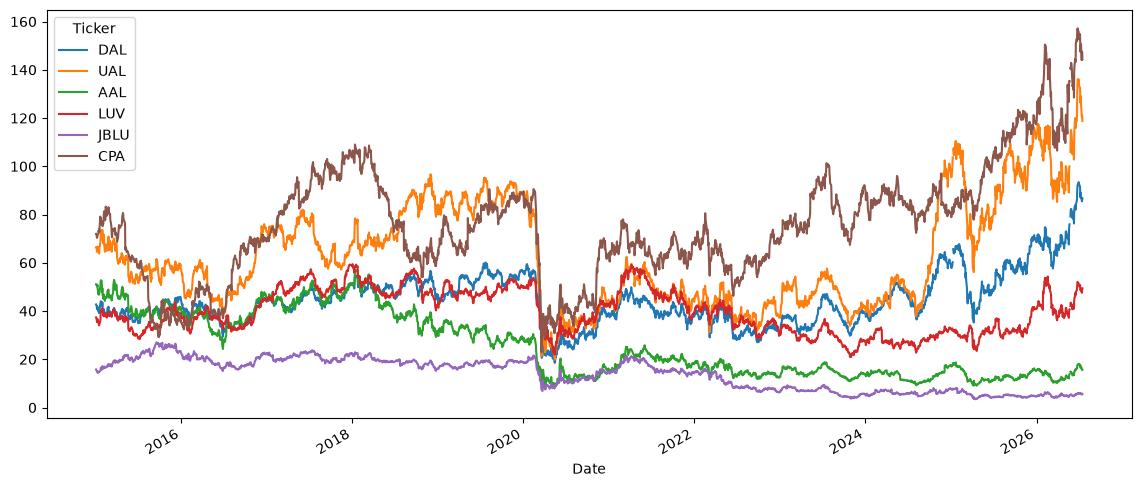

In [8]:
fig, axes = plt.subplots(5, 2, figsize=(16, 10))
axes = axes.flatten()
windows = [20, 30, 45, 60, 90, 180, 240, 300, 360, 420]

for ax, w in zip(axes, windows):
    z = md.compute_rolling_zscore(residuals, window=w).dropna()

    # Count entry signals per ticker
    entries_long  = (z < -bt.entry_threshold).sum().sum()
    entries_short = (z > bt.entry_threshold).sum().sum()

    # Show DAL as representative
    ax.plot(z['DAL'].index, z['DAL'].values,
            linewidth=0.7, color='steelblue', alpha=0.8)
    ax.axhline( bt.entry_threshold, color='green', linestyle='--', linewidth=1.0)
    ax.axhline(-bt.entry_threshold, color='red', linestyle='--', linewidth=1.0)
    ax.axhline( bt.exit_threshold, color='gray', linestyle=':', linewidth=0.6)
    ax.axhline(-bt.exit_threshold, color='gray', linestyle=':', linewidth=0.6)
    ax.set_ylim(-5, 5)
    ax.set_title(f"DAL — Window={w}d  |  Long signals: {entries_long}  "
                 f"Short signals: {entries_short}")

plt.suptitle("Z-Score Window Sensitivity — DAL Residual", fontsize=12)
plt.tight_layout()
plt.show()
prices[["DAL","UAL","AAL","LUV","JBLU","CPA"]].plot(figsize=(14,6))
plt.show

In [24]:
train_air = airline_returns[airline_returns.index <= dt.train_end]
train_macro = macro_returns[macro_returns.index <= dt.train_end]
train_returns = airline_returns[airline_returns.index <= dt.train_end].copy()
train_macro_r = macro_returns[macro_returns.index <= dt.train_end].copy()
covs_train = md.rolling_covariances(train_air, window=md.lookback,
                                     use_ledoit_wolf=True)
_, resid_train, _, _, _ = md.compute_factor_model(
    train_air, covs_train, md.n_components)
conc_train = md.compute_pc1_concentration(covs_train)

print(f"{'Window':>8} {'Signals':>8} {'Sharpe':>8} {'Ann.Ret':>9} {'Ann.Vol':>9} {'Turnover':>10}")
print("─" * 58)

for w in [20, 30, 45, 60, 90, 180, 240, 300, 360, 420]:
    z = md.compute_rolling_zscore(resid_train, window=w).dropna()
    s = bt.generate_signals(z, top_n=bt.top_n, min_hold=bt.min_hold_days)
    p = bt.construct_portfolio(s, zscores=z, residuals=resid_train)
    ps = bt.apply_continuous_concentration_scaling(p, conc_train)
    net, trades = bt.compute_portfolio_returns(ps, train_air)
    net = net.dropna()

    if len(net) < 30:
        print(f"{w:>8}d  insufficient data")
        continue

    ar = net.mean() * 252
    av = net.std() * (252**0.5)
    sr = ar / av if av > 0 else float('nan')
    to = trades['turnover'].mean() * 252
    n_sig = (s != 0).any(axis=1).sum()

    print(f"{w:>7}d  {n_sig:>8}  {sr:>8.3f}  {ar:>9.2%}  {av:>9.2%}  {to:>10.2f}")

  Window  Signals   Sharpe   Ann.Ret   Ann.Vol   Turnover
──────────────────────────────────────────────────────────
     20d      1032    -1.140     -7.20%      6.32%       27.59
     30d      1028    -0.774     -5.11%      6.61%       26.22
     45d      1021    -0.818     -5.45%      6.67%       23.71
     60d      1022    -0.982     -6.62%      6.74%       23.18
     90d       987    -0.924     -5.96%      6.45%       22.77
    180d       971    -0.857     -5.56%      6.48%       20.74
    240d       955    -1.053     -6.65%      6.31%       20.70
    300d       964    -1.286     -8.19%      6.37%       20.54
    360d       969    -1.360     -8.70%      6.40%       20.56
    420d       964    -1.359     -8.59%      6.32%       20.80


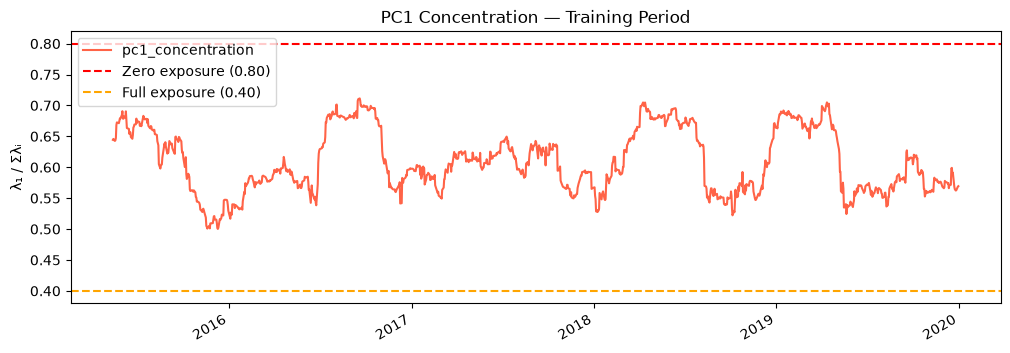

Days above 0.80 (crisis): 0
Days above 0.65: 304


In [10]:
pc1 = md.compute_pc1_concentration(covs)
pc1.plot(figsize=(12,4), color='tomato',
         title="PC1 Concentration — Training Period")
plt.axhline(bt.conc_zero, color='red', linestyle='--', label='Zero exposure (0.80)')
plt.axhline(bt.conc_full, color='orange', linestyle='--', label='Full exposure (0.40)')
plt.ylabel("λ₁ / Σλᵢ")
plt.legend(); plt.show()
print(f"Days above 0.80 (crisis): {(pc1>0.80).sum()}")
print(f"Days above 0.65: {(pc1>0.65).sum()}")

In [26]:
lag_df = md.compute_brent_leadlag(residuals, macro_returns, max_lag=21)


=== Brent Lead-Lag Correlations ===
(negative = Brent rise predicts airline underperformance)
        DAL     UAL     AAL     LUV     ALK    JBLU     CPA
lag                                                        
1   -0.0409  0.0512 -0.0368  0.0250 -0.0420  0.0329  0.0423
2   -0.0232 -0.0230 -0.0108  0.0625 -0.0088  0.0112 -0.0201
3    0.0354  0.0025  0.0152 -0.0100 -0.0475  0.0249 -0.0072
4   -0.0074  0.0019  0.0170 -0.0036  0.0680 -0.0914 -0.0071
5   -0.0731  0.0264 -0.0132  0.0217  0.0190  0.0228 -0.0248
6   -0.0253  0.0002 -0.0094  0.0331  0.0106 -0.0155  0.0249
7   -0.0522 -0.0289  0.0612 -0.0245 -0.0366  0.0511  0.0198
8    0.0116  0.0165  0.0203  0.0030  0.0054 -0.0555 -0.0189
9   -0.0514 -0.0154  0.0106 -0.0019  0.0833 -0.0153  0.0154
10   0.0485 -0.0230  0.0034  0.0748 -0.0706 -0.0310  0.0001
11  -0.0002 -0.0071 -0.0147  0.0057  0.0130 -0.0054  0.0064
12   0.0782 -0.0153 -0.0356 -0.0141 -0.0281  0.0303 -0.0026
13   0.0466  0.0044 -0.0140 -0.0059 -0.0050 -0.0257  0.0165
14   

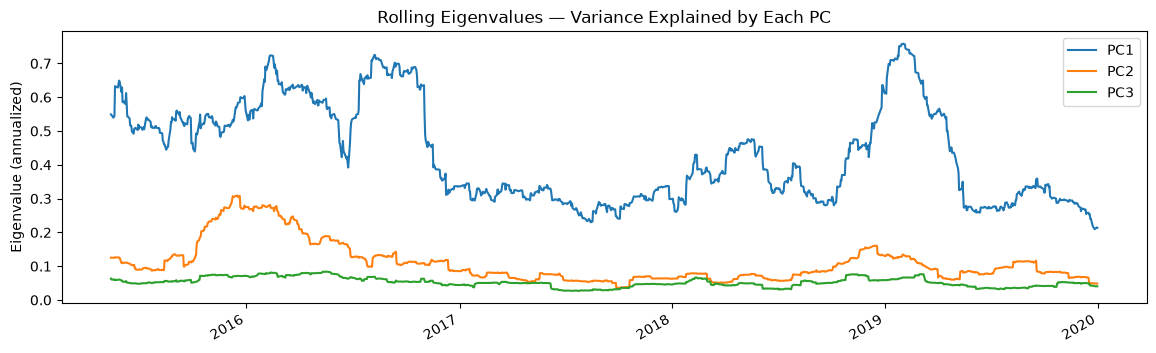

In [27]:
evals_df.plot(figsize=(14,4),title="Rolling Eigenvalues — Variance Explained by Each PC")
plt.ylabel("Eigenvalue (annualized)")
plt.show()

In [28]:
zscores = md.compute_rolling_zscore(residuals, window=zscore_window)
print(zscores.head(15))
print(zscores.isna().sum())

                 DAL       UAL       AAL       LUV       ALK      JBLU  \
2015-05-14       NaN       NaN       NaN       NaN       NaN       NaN   
2015-05-15       NaN       NaN       NaN       NaN       NaN       NaN   
2015-05-18       NaN       NaN       NaN       NaN       NaN       NaN   
2015-05-19       NaN       NaN       NaN       NaN       NaN       NaN   
2015-05-20       NaN       NaN       NaN       NaN       NaN       NaN   
2015-05-21       NaN       NaN       NaN       NaN       NaN       NaN   
2015-05-22       NaN       NaN       NaN       NaN       NaN       NaN   
2015-05-26       NaN       NaN       NaN       NaN       NaN       NaN   
2015-05-27       NaN       NaN       NaN       NaN       NaN       NaN   
2015-05-28 -0.478210  0.217356 -0.096085  0.292973  0.233870 -0.342111   
2015-05-29  0.520786  0.846421 -0.480772 -0.648014 -0.413622  1.079707   
2015-06-01  0.560715 -0.744841  1.121396 -0.433673 -0.955281  1.095406   
2015-06-02 -1.900903  1.055982  0.4526